<a href="https://colab.research.google.com/github/timfan705/CAmarket/blob/main/cmpe188_CAmarket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step needed to be made:**
* Data Aquisition - we need more data sets; i think 4 is a safe bet
* Key features we want to include in our ML App (Location, Median Income, Average house price given size like 3b2b, etc)
* Which ML model to use
* Actual Coding (Training model, frontend)
* Testing and Validation


# Data Aquisition Step


In [1]:
# Installing dependencies
!pip install pandas scikit-learn --quiet

In [2]:
# Adding imports
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import os

In [3]:
# Creating a directory structure
os.makedirs("data/raw", exist_ok=True)
print("Directories created")

Directories created


In [4]:
# Loading the sklearn dataset
sklearn_housing = fetch_california_housing(as_frame=True)
df_sklearn = sklearn_housing.frame
df_sklearn.rename(columns={"MedHouseVal": "median_house_value"}, inplace=True)

print(f" sklearn loaded | Shape: {df_sklearn.shape}")
print(df_sklearn.head())

 sklearn loaded | Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  median_house_value  
0    -122.23               4.526  
1    -122.22               3.585  
2    -122.24               3.521  
3    -122.25               3.413  
4    -122.25               3.422  


In [5]:
# Load Zillow CSV directly from GitHub (no upload needed)
import pandas as pd

z_url = "https://raw.githubusercontent.com/timfan705/CAmarket/main/zillow.csv"
df_zillow_raw = pd.read_csv(z_url, low_memory=False)

print("Raw Zillow shape:", df_zillow_raw.shape)
print(df_zillow_raw.head())
print("RegionType counts:\n", df_zillow_raw["RegionType"].value_counts())

Raw Zillow shape: (895, 320)
   RegionID  SizeRank       RegionName RegionType StateName     2000-01-31  \
0    102001         0    United States    country       NaN  122723.314722   
1    394913         1     New York, NY        msa        NY  217784.554624   
2    753899         2  Los Angeles, CA        msa        CA  224762.443660   
3    394463         3      Chicago, IL        msa        IL  153387.535332   
4    394514         4       Dallas, TX        msa        TX  129543.865799   

      2000-02-29     2000-03-31     2000-04-30     2000-05-31  ...  \
0  122939.224374  123206.984135  123781.276262  124442.217647  ...   
1  218710.016103  219644.049023  221536.761145  223496.730091  ...   
2  225598.845127  226712.923903  228929.566423  231353.878418  ...   
3  153529.527506  153799.954104  154472.708272  155281.950617  ...   
4  129601.565090  129667.896331  129840.151596  130067.265447  ...   

      2025-06-30     2025-07-31     2025-08-31     2025-09-30     2025-10-31  \
0

In [6]:
# Keep only California MSAs (this Zillow file is MSA-only + country)
df_zillow_ca = df_zillow_raw[
    (df_zillow_raw["RegionType"] == "msa") &
    (df_zillow_raw["StateName"] == "CA")
].copy()

# Identify date columns and pick the latest one
meta_cols = ["RegionID","SizeRank","RegionName","RegionType","StateName"]
date_cols = sorted([c for c in df_zillow_raw.columns if c not in meta_cols], key=pd.to_datetime)

latest_col = date_cols[-1]  # e.g., "2026-03-31"
print("Using latest Zillow column:", latest_col)

# Build a simple lookup table: RegionName -> latest Zillow value
df_zillow_latest = df_zillow_ca[["RegionName"]].copy()
df_zillow_latest["zillow_median_price"] = df_zillow_ca[latest_col].astype(float)

print("Zillow CA latest prices | Shape:", df_zillow_latest.shape)
print(df_zillow_latest.head())

Using latest Zillow column: 2026-03-31
Zillow CA latest prices | Shape: (34, 2)
           RegionName  zillow_median_price
2     Los Angeles, CA         9.678362e+05
12  San Francisco, CA         1.143246e+06
13      Riverside, CA         5.851806e+05
17      San Diego, CA         9.419345e+05
26     Sacramento, CA         5.800060e+05


# Data Cleaning and Merging Step

In [7]:
# Check for nulls and data types
# first inspect the sklearn dataset
print(" sklearn Dataset ")
print(df_sklearn.shape)
print(df_sklearn.isnull().sum())
print(df_sklearn.dtypes)
print(df_sklearn.describe())

# second inspect zillow data set
print(" Zillow Dataset ")
print(df_zillow_latest.shape)
print(df_zillow_latest.isnull().sum())
print(df_zillow_latest.head(10))

 sklearn Dataset 
(20640, 9)
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
median_house_value    0
dtype: int64
MedInc                float64
HouseAge              float64
AveRooms              float64
AveBedrms             float64
Population            float64
AveOccup              float64
Latitude              float64
Longitude             float64
median_house_value    float64
dtype: object
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079  

## MSA Mapping (Latitude/Longitude → Zillow RegionName)

In [8]:
import pandas as pd

msa_centroids = pd.DataFrame({
    "RegionName": [
        "Bakersfield, CA","Chico, CA","Clearlake, CA","Crescent City, CA","El Centro, CA",
        "Eureka, CA","Fresno, CA","Hanford, CA","Los Angeles, CA","Madera, CA","Merced, CA",
        "Modesto, CA","Napa, CA","Oxnard, CA","Red Bluff, CA","Redding, CA","Riverside, CA",
        "Sacramento, CA","Salinas, CA","San Diego, CA","San Francisco, CA","San Jose, CA",
        "San Luis Obispo, CA","Santa Cruz, CA","Santa Maria, CA","Santa Rosa, CA","Sonora, CA",
        "Stockton, CA","Susanville, CA","Truckee, CA","Ukiah, CA","Vallejo, CA","Visalia, CA",
        "Yuba City, CA"
    ],
    "msa_lat": [
        35.3733,39.7285,38.9582,41.7558,32.7920,
        40.8021,36.7378,36.3275,34.0522,36.9613,37.3022,
        37.6391,38.2975,34.1975,40.1785,40.5865,33.9806,
        38.5816,36.6777,32.7157,37.7749,37.3382,
        35.2828,36.9741,34.9530,38.4405,37.9841,
        37.9577,40.4163,39.3279,39.1502,38.1041,36.3302,
        39.1404
    ],
    "msa_lon": [
        -119.0187,-121.8375,-122.6264,-124.2026,-115.5631,
        -124.1637,-119.7871,-119.6457,-118.2437,-120.0607,-120.4820,
        -120.9969,-122.2869,-119.1771,-122.2358,-122.3917,-117.3755,
        -121.4944,-121.6555,-117.1611,-122.4194,-121.8863,
        -120.6596,-122.0308,-120.4357,-122.7144,-120.3822,
        -121.2908,-120.6530,-120.1833,-123.2078,-122.2566,-119.2921,
        -121.6169
    ]
})

print("Centroids table shape:", msa_centroids.shape)
msa_centroids.head()

Centroids table shape: (34, 3)


,RegionName,msa_lat,msa_lon
0,"Bakersfield, CA",35.3733,-119.0187
1,"Chico, CA",39.7285,-121.8375
2,"Clearlake, CA",38.9582,-122.6264
3,"Crescent City, CA",41.7558,-124.2026
4,"El Centro, CA",32.7920,-115.5631


## Centroid Coverage Checks

In [9]:
# 1) Make sure every Zillow CA MSA has a centroid
missing = sorted(set(df_zillow_latest["RegionName"]) - set(msa_centroids["RegionName"]))
print("Missing centroids:", missing)

# 2) Make sure the centroid join didn’t drop anything unexpectedly
z_geo = df_zillow_latest.merge(msa_centroids, on="RegionName", how="inner")
print("df_zillow_latest:", df_zillow_latest.shape)
print("z_geo:", z_geo.shape)

Missing centroids: []
df_zillow_latest: (34, 2)
z_geo: (34, 4)


## Merge: Assign Rows to MSAs and Join Zillow Feature

In [10]:
# Assign each sklearn row to nearest MSA centroid, then merge Zillow
df_tmp = df_sklearn.copy()

lat = df_tmp["Latitude"].to_numpy()[:, None]
lon = df_tmp["Longitude"].to_numpy()[:, None]
msa_lat = z_geo["msa_lat"].to_numpy()[None, :]
msa_lon = z_geo["msa_lon"].to_numpy()[None, :]

dist2 = (lat - msa_lat)**2 + (lon - msa_lon)**2
nearest = dist2.argmin(axis=1)

df_tmp["msa_name"] = z_geo["RegionName"].to_numpy()[nearest]

df_merged = df_tmp.merge(
    z_geo[["RegionName", "zillow_median_price"]],
    left_on="msa_name",
    right_on="RegionName",
    how="left"
).drop(columns=["RegionName"])

print("Merged dataset shape:", df_merged.shape)
print("Missing Zillow values:", df_merged["zillow_median_price"].isna().sum())

# Guards
assert df_merged["zillow_median_price"].isna().sum() == 0
assert df_merged.isna().sum().sum() == 0

# Preview + validation summary
display(df_merged.head(10))

summary = pd.DataFrame({
    "dtype": df_merged.dtypes.astype(str),
    "missing": df_merged.isna().sum(),
    "missing_%": (df_merged.isna().mean() * 100).round(2),
})
display(summary)

display(df_merged["msa_name"].value_counts().rename_axis("msa_name").reset_index(name="n_rows"))

Merged dataset shape: (20640, 11)
Missing Zillow values: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value,msa_name,zillow_median_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,"San Francisco, CA",1.143246e+06
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,"San Francisco, CA",1.143246e+06
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,"San Francisco, CA",1.143246e+06
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,"San Francisco, CA",1.143246e+06
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,"San Francisco, CA",1.143246e+06
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697,"San Francisco, CA",1.143246e+06
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992,"San Francisco, CA",1.143246e+06
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414,"San Francisco, CA",1.143246e+06
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267,"San Francisco, CA",1.143246e+06
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611,"San Francisco, CA",1.143246e+06


,dtype,missing,missing_%
MedInc,float64,0,0.0
HouseAge,float64,0,0.0
AveRooms,float64,0,0.0
AveBedrms,float64,0,0.0
Population,float64,0,0.0
AveOccup,float64,0,0.0
Latitude,float64,0,0.0
Longitude,float64,0,0.0
median_house_value,float64,0,0.0
msa_name,object,0,0.0


,msa_name,n_rows
0,"Los Angeles, CA",6867
1,"Riverside, CA",1958
2,"San Francisco, CA",1920
3,"San Diego, CA",1585
4,"San Jose, CA",1337
5,"Sacramento, CA",890
6,"Vallejo, CA",572
7,"Oxnard, CA",547
8,"Stockton, CA",452
9,"Fresno, CA",442


In [11]:
# create a new save file for a merged dataset

os.makedirs("data/processed", exist_ok=True)
df_merged.to_csv("data/processed/merged_housing.csv", index=False)

print("Merged dataset saved to data/processed/merged_housing.csv")
print(df_merged.head())

Merged dataset saved to data/processed/merged_housing.csv
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  median_house_value           msa_name  zillow_median_price  
0    -122.23               4.526  San Francisco, CA         1.143246e+06  
1    -122.22               3.585  San Francisco, CA         1.143246e+06  
2    -122.24               3.521  San Francisco, CA         1.143246e+06  
3    -122.25               3.413  San Francisco, CA         1.143246e+06  
4    -122.25               3.422  San Francisco, CA         1.143246e+06  


# Visualization of Current Dataset

In [12]:
!pip install matplotlib seaborn folium --quiet

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

# Set default plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Histogram Comparison: Housing Values (sklearn) vs Zillow Prices

=== Dataset Overview ===
Shape: (20640, 11)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'median_house_value', 'msa_name', 'zillow_median_price']

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value,zillow_median_price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558,8.575785e+05
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956,3.165025e+05
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,2.310855e+05
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000,5.851806e+05
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,9.678362e+05
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,9.678362e+05
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,1.636393e+06


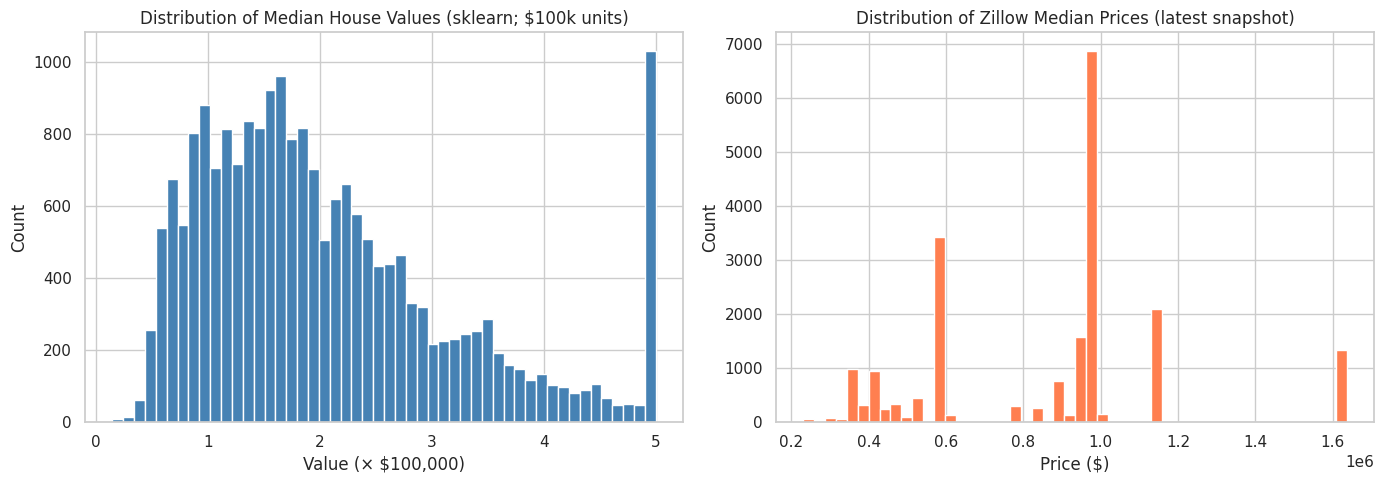

Saved: eda_price_distribution.png


In [14]:
print("=== Dataset Overview ===")
print(f"Shape: {df_merged.shape}")
print(f"\nColumn Names:\n{df_merged.columns.tolist()}")
print("\nBasic Statistics:")
display(df_merged.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sklearn prices (1990)
axes[0].hist(df_merged["median_house_value"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Median House Values (sklearn; $100k units)")
axes[0].set_xlabel("Value (× $100,000)")
axes[0].set_ylabel("Count")

# Zillow prices (current)
axes[1].hist(df_merged["zillow_median_price"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Zillow Median Prices (latest snapshot)")
axes[1].set_xlabel("Price ($)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_price_distribution.png")

## Correlation Analysis (Numeric Features)

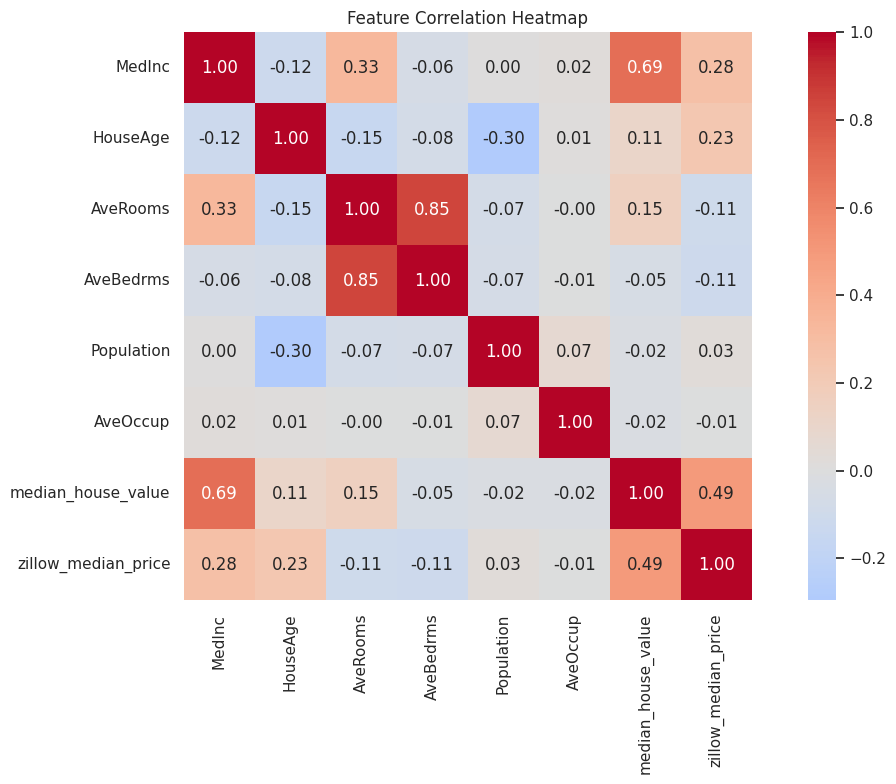

Saved: eda_correlation_heatmap.png


In [15]:
# Feature correlation heatmap (numeric only)
numeric_cols = df_merged.select_dtypes(include=[np.number]).drop(
    columns=["Latitude", "Longitude"],
    errors="ignore"
)

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_correlation_heatmap.png")

## Relationship: Median Income vs Zillow Price


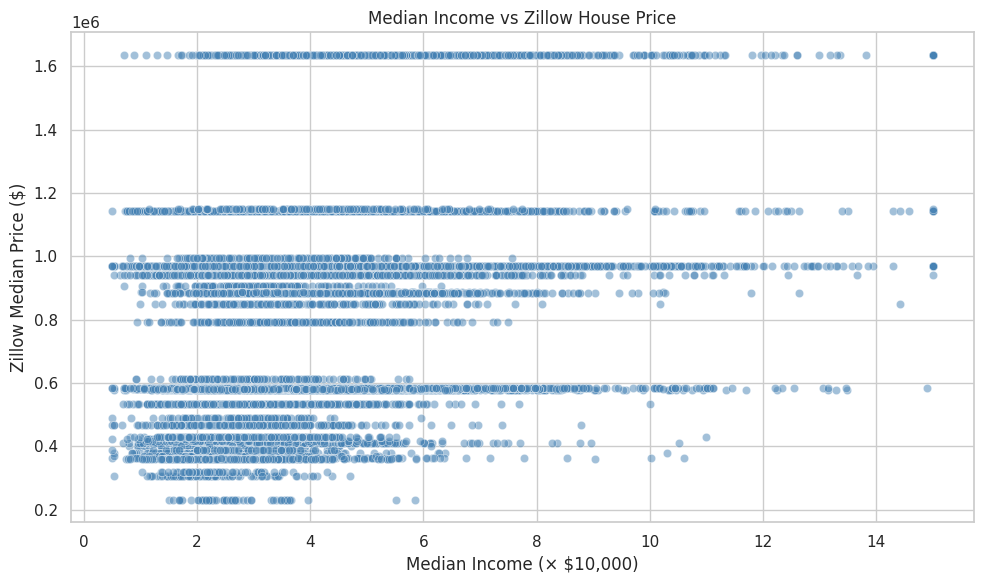

Saved: eda_income_vs_price.png


In [16]:
# income vs price plot
# higher income neighborhoods tend to have higher house prices

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged,
    x="MedInc",
    y="zillow_median_price",
    alpha=0.5,
    color="steelblue"
)
plt.title("Median Income vs Zillow House Price")
plt.xlabel("Median Income (× $10,000)")
plt.ylabel("Zillow Median Price ($)")
plt.tight_layout()
plt.savefig("eda_income_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_income_vs_price.png")

## Relationship: House Age vs Zillow Price

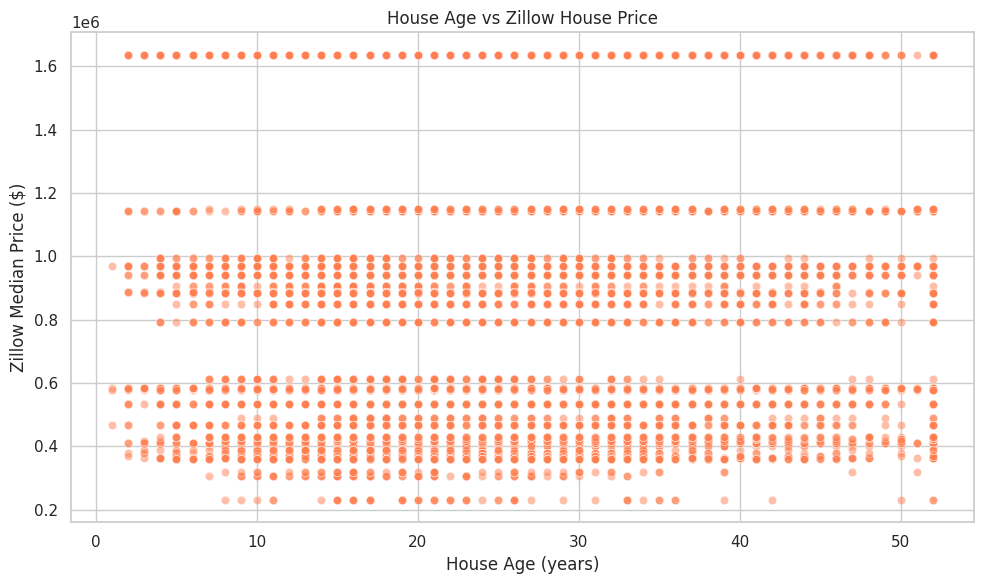

House age vs price scatter plotted


In [17]:
# age of the house vs price plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged,
    x="HouseAge",
    y="zillow_median_price",
    alpha=0.5,
    color="coral"
)
plt.title("House Age vs Zillow House Price")
plt.xlabel("House Age (years)")
plt.ylabel("Zillow Median Price ($)")
plt.tight_layout()
plt.savefig("eda_age_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("House age vs price scatter plotted")

## Geospatial Heatmap: Zillow Price Intensity Across California

In [18]:
# Prepare heatmap data [lat, lon, weight] with normalized weights
heat_df = df_merged[["Latitude", "Longitude", "zillow_median_price"]].dropna().copy()

w = heat_df["zillow_median_price"].to_numpy()
w_norm = (w - w.min()) / (w.max() - w.min())

heat_data = np.column_stack([
    heat_df["Latitude"].to_numpy(),
    heat_df["Longitude"].to_numpy(),
    w_norm
]).tolist()

# Create a base map centered on California
ca_map = folium.Map(location=[36.7783, -119.4179], zoom_start=6)

# Add heatmap layer
HeatMap(heat_data, radius=8, blur=10, max_zoom=1).add_to(ca_map)

ca_map.save("eda_ca_heatmap.html")
ca_map

## Top 10 Most Expensive California MSAs (Zillow)

/tmp/ipykernel_31334/2628497418.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_msas.values, y=top_msas.index, palette="Reds_r")


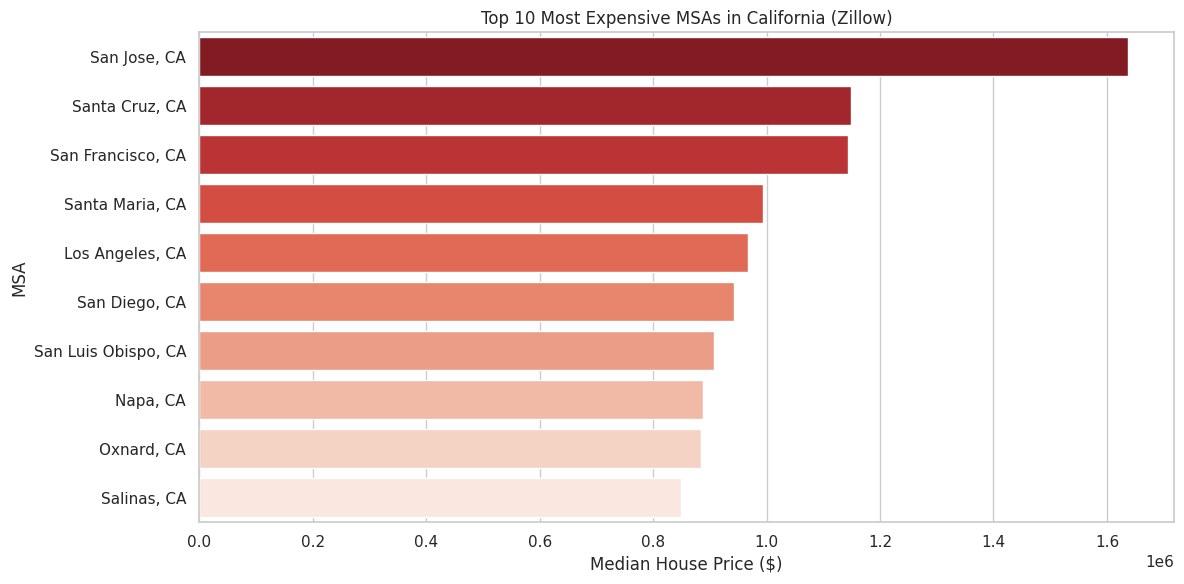

Saved: eda_top_msas.png


In [19]:
# Top most expensive MSAs (by Zillow median price)
top_msas = (
    df_merged.groupby("msa_name")["zillow_median_price"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_msas.values, y=top_msas.index, palette="Reds_r")
plt.title("Top 10 Most Expensive MSAs in California (Zillow)")
plt.xlabel("Median House Price ($)")
plt.ylabel("MSA")
plt.tight_layout()
plt.savefig("eda_top_msas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_top_msas.png")